In [1]:
# Import the kagglehub library.
# kagglehub provides tools to download/access datasets from Kaggle.
import kagglehub


# Download the Kaggle dataset.
#
# "salader/dogsvscats" is the Kaggle dataset identifier:
#
#     salader   → Kaggle username of the dataset owner
#     dogsvscats → name/slug of the dataset
#
# dataset_download() downloads the dataset and returns
# the location (path) where the dataset is available in Colab.
path = kagglehub.dataset_download("salader/dogsvscats")


# Print the path returned by kagglehub.
# This tells us where the dataset is located in the Colab environment.
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [2]:
import os

# `path` contains the location of our Kaggle dataset
print(os.listdir(path))

['test', 'train', 'catsvsdogs']


In [3]:
#!          → Run a terminal command
#cp         → Copy
#-r         → Copy recursively (folder + everything inside)
#SOURCE     → /kaggle/input/dogsvscats
#DESTINATION→ /content/
!cp -r /kaggle/input/dogsvscats /content/

In [15]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout


In [6]:
# Create a TensorFlow dataset from images stored in folders.
train_data = keras.utils.image_dataset_from_directory(

    # Tell Keras where the training images are located.
    directory='/content/train',

    # Automatically create labels from the names of the subfolders.
    labels="inferred",

    # Represent each class label as an integer such as 0, 1, 2...
    label_mode="int",

    # Load 32 images together as one batch.
    batch_size=32,

    # Resize every image to 256 × 256 pixels.
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.


In [7]:

validation_data = keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

Found 5000 files belonging to 2 classes.


In [8]:
# Normalize the image pixel values from 0–255 to 0–1.
def process(image, label):

    # Convert the image values to float32 after dividing them by 255.
    image = tf.cast(image / 255., tf.float32)

    # Return the normalized image together with its original label.
    return image, label


# Apply the process function to every image and label in the training dataset.
train_data = train_data.map(process)

# Apply the process function to every image and label in the validation dataset.
validation_data = validation_data.map(process)

In [57]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(BatchNormalization())

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(BatchNormalization())

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(BatchNormalization())

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 127, 127, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [59]:
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy' ])

In [60]:
history = model.fit(train_data,epochs=10,validation_data=validation_data)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.5660 - loss: 2.7521 - val_accuracy: 0.5988 - val_loss: 0.6573
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.6347 - loss: 0.6529 - val_accuracy: 0.6866 - val_loss: 0.6060
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.6879 - loss: 0.5898 - val_accuracy: 0.6380 - val_loss: 0.5956
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.7335 - loss: 0.5382 - val_accuracy: 0.6058 - val_loss: 0.6725
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.7649 - loss: 0.4915 - val_accuracy: 0.7516 - val_loss: 0.5030
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 87ms/step - accuracy: 0.7929 - loss: 0.4472 - val_accuracy: 0.7756 - val_loss: 0.4612
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8185 - loss: 0.4025 - val_accuracy: 0.8068 - val_loss: 0.4071
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8498 - loss: 0.3378 - 

# Val_accuracy is 68 % and Accuracy is 91 %

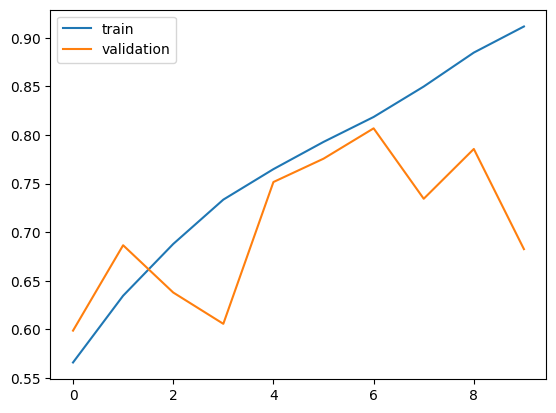

In [61]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy' ], label='validation')
plt.legend()
plt.show()

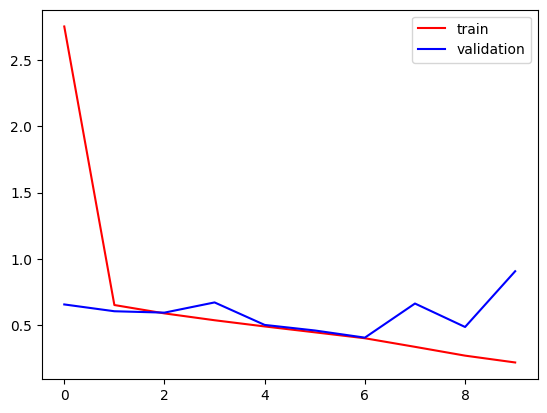

In [64]:
plt.plot(history.history['loss' ], color='red', label='train')
plt.plot(history.history['val_loss' ], color='blue', label='validation')
plt.legend()
plt.show()

In [65]:
# ways to reduce overfitting

# Add more data
# Data Augmentation -> next video
# L1/L2 Regularizer
# Dropout
# Batch Norm
# Reduce complexity

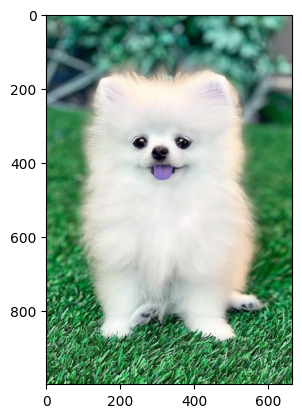

In [66]:
# Import OpenCV for reading and processing images.
import cv2

# Read the image from the specified path.
test_img = cv2.imread('/content/dog.jpg')

# Display the image using Matplotlib.
plt.imshow(test_img)

In [67]:
# Check the shape (height, width, and color channels) of the image.
test_img.shape

(1000, 666, 3)

In [68]:
# Resize the image to 256 × 256 pixels.
test_img = cv2.resize(test_img, (256, 256))

# 1 Means Dog and 0 means Cat

In [69]:
# Add a batch dimension to make the image shape (1, 256, 256, 3).
test_input = test_img.reshape((1, 256, 256, 3))

# Pass the image to the trained model and get its prediction.
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step


array([[1.]], dtype=float32)

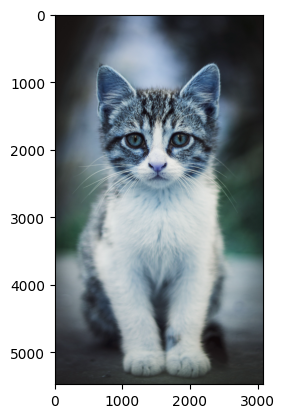

In [76]:
import cv2

test_img_cat = cv2.imread('/content/cats.jpg')

plt.imshow(test_img_cat)

In [77]:
test_img_cat.shape

(5472, 3078, 3)

In [78]:
test_img_cat = cv2.resize(test_img_cat,(256,256))

In [79]:
test_input_1 = test_img_cat.reshape((1,256,256,3))
model.predict(test_input_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[0.]], dtype=float32)

# Here U can see that 1 is for the dog and the 0 is for the cat